# AI-Powered Credit Risk Analytics

## Project Overview

This project analyzes customer credit risk data to identify delinquency patterns and build a predictive framework for credit risk assessment.

## Objectives

- Perform data cleaning and preprocessing
- Conduct exploratory data analysis (EDA)
- Identify key delinquency risk factors
- Build a machine learning model for delinquency prediction
- Generate business recommendations

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Data Loading

Load the customer delinquency dataset and inspect its structure.

In [2]:
df = pd.read_csv(
    "data/Delinquency_prediction_dataset.csv"
)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/Delinquency_prediction_dataset.csv'

# Dataset Overview

Understand dataset dimensions, variable types, and basic statistics.

In [ ]:
print(df.shape)

(500, 19)


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    str    
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    str    
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    str    
 12  Location              500 non-null    str    
 13  Month_1               500 non-null    str    
 14  Month_2               500 non-null    str    
 15  Month_3               500 non-null

In [ ]:
df.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.000000,500.000000
mean,46.266000,108379.893709,577.716867,0.491446,2.968000,0.160000,48654.428875,0.298862,9.740000
std,16.187629,53662.723741,168.881211,0.197103,1.946935,0.366973,29395.537273,0.094521,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,0.000000
25%,33.000000,62295.000000,418.250000,0.356486,1.000000,0.000000,23716.500000,0.233639,5.000000
50%,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,10.000000
75%,59.250000,155734.000000,727.250000,0.634440,5.000000,0.000000,75546.500000,0.362737,15.000000
max,74.000000,199943.000000,847.000000,1.025843,6.000000,1.000000,99620.000000,0.552956,19.000000


# Missing Value Analysis

Identify columns containing missing values.

In [ ]:
df.isnull().sum()

Customer_ID              0
Age                      0
Income                  39
Credit_Score             2
Credit_Utilization       0
Missed_Payments          0
Delinquent_Account       0
Loan_Balance            29
Debt_to_Income_Ratio     0
Employment_Status        0
Account_Tenure           0
Credit_Card_Type         0
Location                 0
Month_1                  0
Month_2                  0
Month_3                  0
Month_4                  0
Month_5                  0
Month_6                  0
dtype: int64

# Data Cleaning

Handle missing values using median imputation for numerical variables.

In [ ]:
for col in [
    "Income",
    "Credit_Score",
    "Loan_Balance"
]:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [ ]:
df.isnull().sum()

Customer_ID             0
Age                     0
Income                  0
Credit_Score            0
Credit_Utilization      0
Missed_Payments         0
Delinquent_Account      0
Loan_Balance            0
Debt_to_Income_Ratio    0
Employment_Status       0
Account_Tenure          0
Credit_Card_Type        0
Location                0
Month_1                 0
Month_2                 0
Month_3                 0
Month_4                 0
Month_5                 0
Month_6                 0
dtype: int64

# Duplicate Record Analysis

Check for duplicate customer records.

In [ ]:
df.duplicated().sum()

np.int64(0)

# Data Standardization

Standardize employment status values.

In [ ]:
df["Employment_Status"] = (
    df["Employment_Status"]
    .replace(
        ["EMP","employed"],
        "Employed"
    )
)

In [ ]:
df["Employment_Status"].value_counts()

Employment_Status
Employed         240
Unemployed        93
retired           87
Self-employed     80
Name: count, dtype: int64

# Exploratory Data Analysis

Analyze customer delinquency patterns.

## Delinquency Distribution

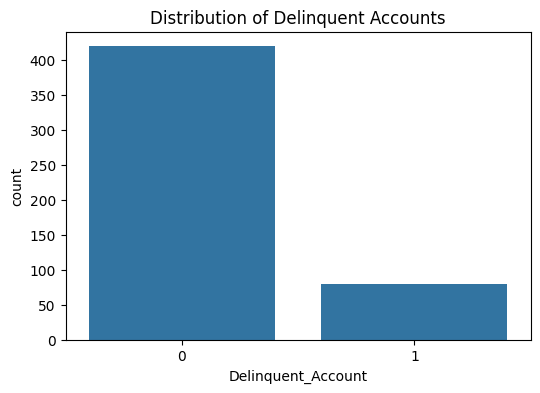

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Delinquent_Account",
    data=df
)

plt.title(
    "Distribution of Delinquent Accounts"
)

plt.show()

# Numerical Feature Analysis

Analyze the distribution of important numerical variables and identify potential risk patterns.

## Credit Score Distribution

Understanding the overall credit score profile of customers.

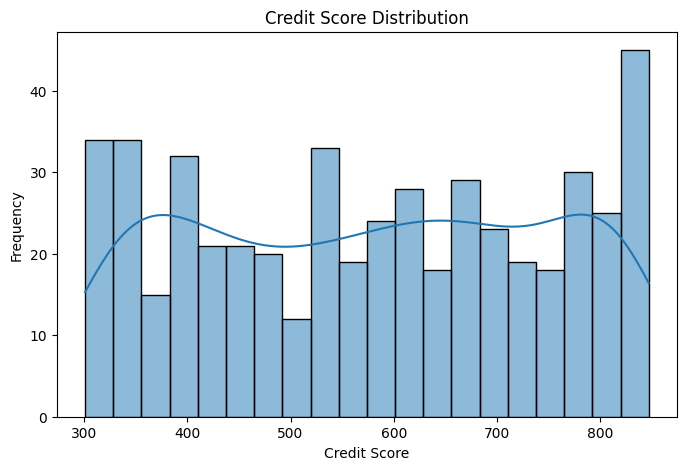

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Credit_Score"],
    bins=20,
    kde=True
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

## Income Distribution

Analyze customer income levels.

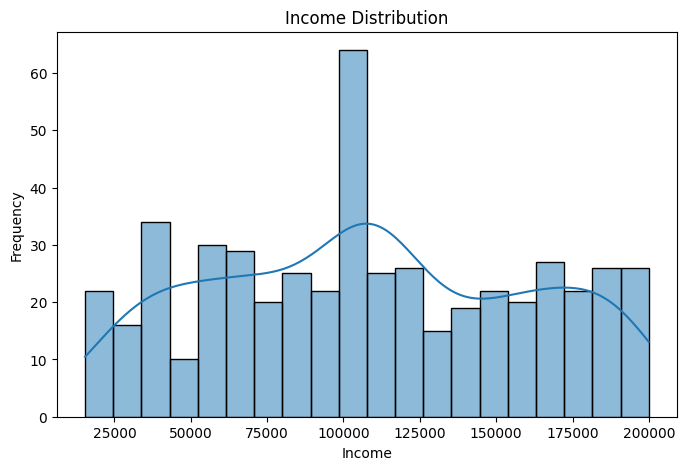

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Income"],
    bins=20,
    kde=True
)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

# Delinquency vs Numerical Features

Compare distributions between delinquent and non-delinquent customers.

## Credit Score vs Delinquency

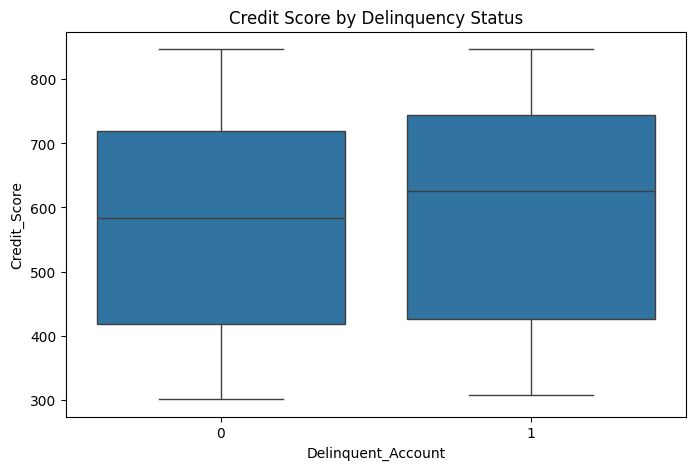

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Credit_Score",
    data=df
)

plt.title("Credit Score by Delinquency Status")

plt.show()

## Credit Utilization vs Delinquency

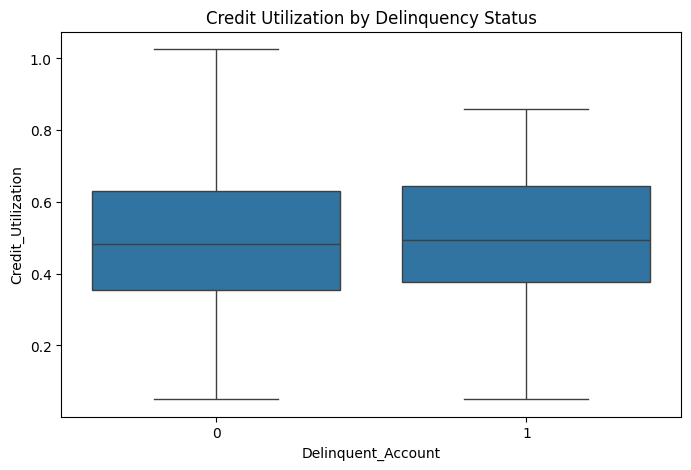

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Credit_Utilization",
    data=df
)

plt.title("Credit Utilization by Delinquency Status")

plt.show()

## Missed Payments vs Delinquency

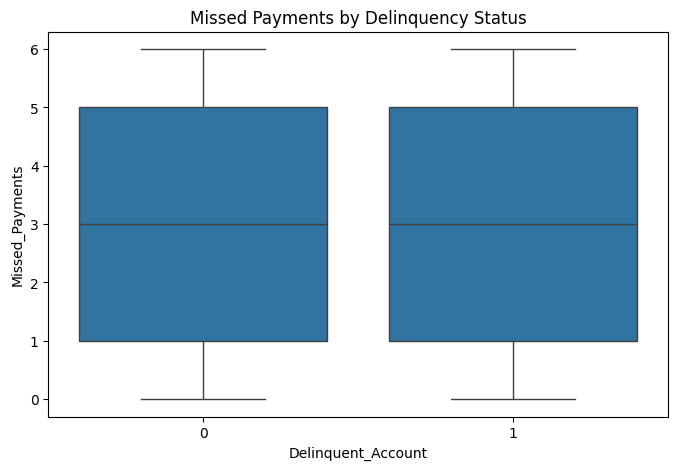

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Missed_Payments",
    data=df
)

plt.title("Missed Payments by Delinquency Status")

plt.show()

# Categorical Feature Analysis

Evaluate delinquency patterns across customer categories.

## Delinquency by Employment Status

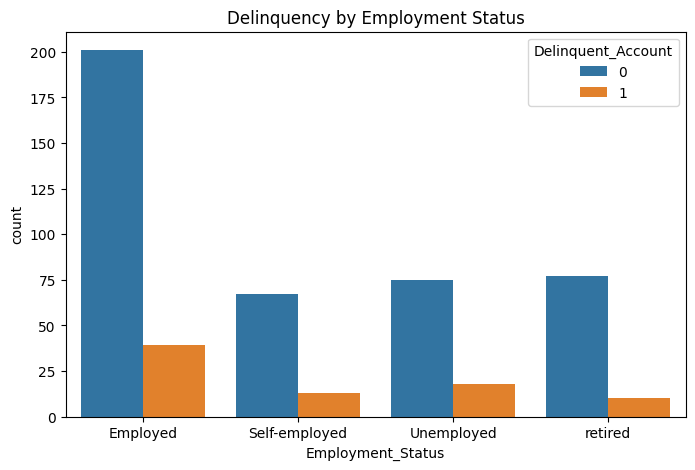

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Employment_Status",
    hue="Delinquent_Account",
    data=df
)

plt.title("Delinquency by Employment Status")

plt.show()

## Delinquency by Credit Card Type

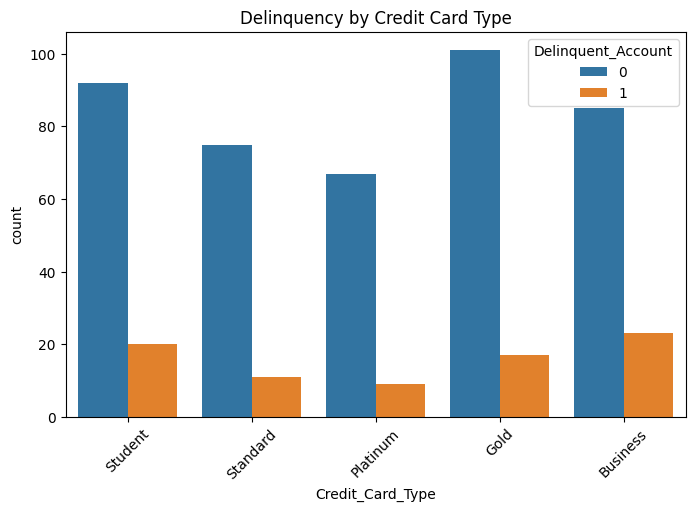

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Credit_Card_Type",
    hue="Delinquent_Account",
    data=df
)

plt.title("Delinquency by Credit Card Type")

plt.xticks(rotation=45)

plt.show()

# Correlation Analysis

Identify relationships between numerical variables.

In [ ]:
numerical_cols = df.select_dtypes(
    include=["int64","float64"]
)

corr_matrix = numerical_cols.corr()

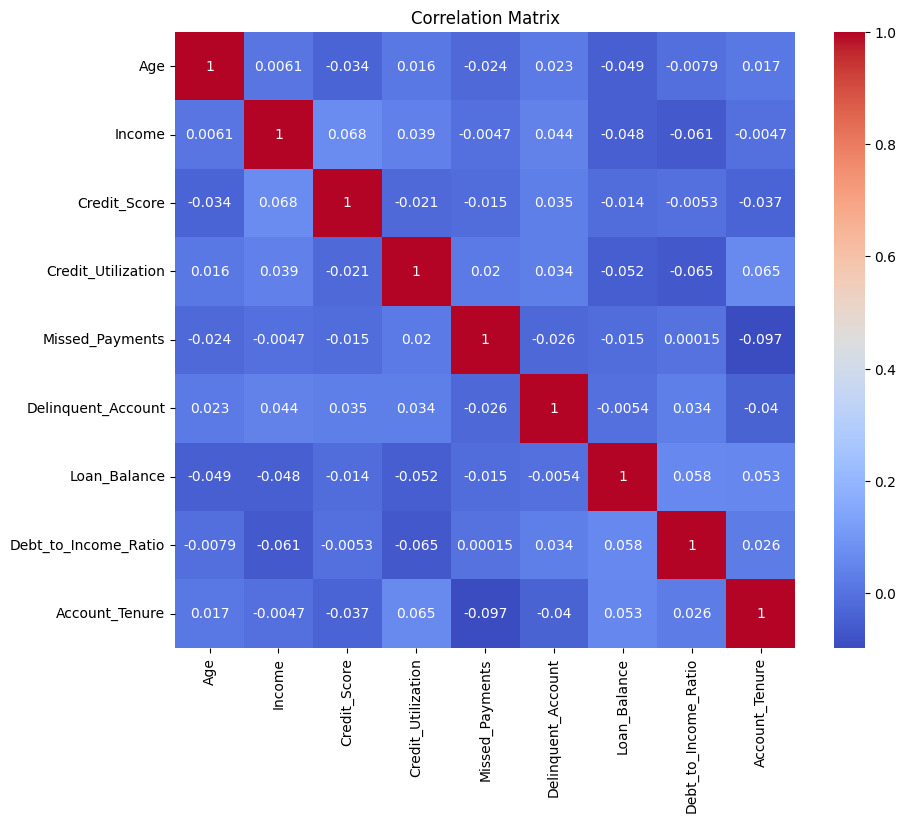

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Key Findings

### Major Risk Indicators

- Customers with lower credit scores show higher delinquency risk.
- Higher credit utilization is associated with delinquent accounts.
- Customers with multiple missed payments are more likely to become delinquent.
- Certain employment categories exhibit higher delinquency rates.
- Credit card type influences delinquency behavior.

### Business Implications

- High-risk customers should receive proactive intervention.
- Credit utilization should be monitored closely.
- Missed payment behavior is a strong early warning signal.

# Feature Engineering

Create additional variables that improve predictive power and business interpretation.

## Credit Score Risk Category

In [ ]:
def credit_score_risk(score):
    if score < 600:
        return "High Risk"
    elif score < 750:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk_Segment"] = df["Credit_Score"].apply(
    credit_score_risk
)

df["Risk_Segment"].value_counts()

Risk_Segment
High Risk      260
Medium Risk    130
Low Risk       110
Name: count, dtype: int64

## Credit Utilization Category

In [ ]:
def utilization_category(x):
    if x < 0.30:
        return "Low Utilization"
    elif x < 0.70:
        return "Moderate Utilization"
    else:
        return "High Utilization"

df["Utilization_Category"] = (
    df["Credit_Utilization"]
    .apply(utilization_category)
)

df["Utilization_Category"].value_counts()

Utilization_Category
Moderate Utilization    348
Low Utilization          83
High Utilization         69
Name: count, dtype: int64

# Data Preparation

Prepare features and target variable for machine learning.

In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure',
       'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6', 'Risk_Segment',
       'Utilization_Category'],
      dtype='str')

In [ ]:
y = df["Delinquent_Account"]

In [ ]:
X = df[
    [
        "Income",
        "Credit_Score",
        "Loan_Balance",
        "Credit_Utilization",
        "Debt_to_Income_Ratio",
        "Missed_Payments"
    ]
]

# Train-Test Split

Split data into training and testing datasets.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(400, 6)
(100, 6)


# Logistic Regression Model

Build a baseline model for delinquency prediction.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

# Model Predictions

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred[:10]

array([1, 0, 1, 1, 0, 1, 1, 0, 1, 0])

# Model Evaluation

Evaluate model performance using classification metrics.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
accuracy_score(
    y_test,
    y_pred
)

0.43

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[37, 49],
       [ 8,  6]])

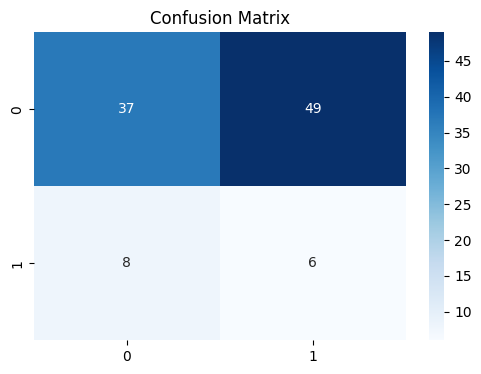

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.43      0.56        86
           1       0.11      0.43      0.17        14

    accuracy                           0.43       100
   macro avg       0.47      0.43      0.37       100
weighted avg       0.72      0.43      0.51       100



# Evaluating RandomForest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        86
           1       0.00      0.00      0.00        14

    accuracy                           0.86       100
   macro avg       0.43      0.50      0.46       100
weighted avg       0.74      0.86      0.80       100



c:\Users\Kunal Sawant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kunal Sawant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kunal Sawant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [ ]:
confusion_matrix(y_test, rf_pred)

array([[86,  0],
       [14,  0]])

# Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
4,Debt_to_Income_Ratio,0.200870
3,Credit_Utilization,0.189789
1,Credit_Score,0.185532
0,Income,0.179094
2,Loan_Balance,0.159025
5,Missed_Payments,0.085690


<Axes: xlabel='Importance', ylabel='Feature'>

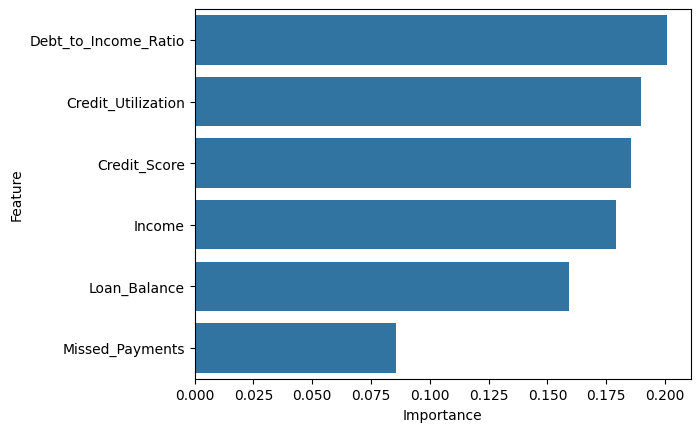

In [ ]:
sns.barplot(
    data=feature_importance.sort_values(
        by='Importance',
        ascending=False
    ),
    x='Importance',
    y='Feature'
)

# Business Interpretation

## Model Summary

This project analyzed customer credit risk data to identify factors associated with delinquent accounts and evaluate the feasibility of predicting delinquency using machine learning techniques. Exploratory Data Analysis (EDA) revealed that variables such as **Credit Score, Credit Utilization, Missed Payments, Debt-to-Income Ratio, and Loan Balance** have a significant influence on customer repayment behavior.

Two machine learning models, **Logistic Regression** and **Random Forest**, were developed to predict delinquency risk. However, due to the imbalanced nature of the dataset (**84% non-delinquent and 16% delinquent customers**), the models struggled to accurately identify delinquent customers. This highlights a common challenge in real-world credit risk analytics where class imbalance can significantly impact predictive performance.

## Business Applications

- Identify customers exhibiting high-risk financial behavior for proactive monitoring.
- Prioritize collection efforts toward customers with multiple missed payments and high credit utilization.
- Support credit risk assessment and customer segmentation strategies.
- Enable data-driven decision-making for customer outreach and intervention programs.
- Improve understanding of factors contributing to delinquency and potential default risk.

# Project Conclusion

This project successfully applied data cleaning, exploratory data analysis, visualization, and machine learning techniques to investigate customer delinquency patterns and credit risk behavior.

The analysis identified **Credit Score, Credit Utilization, Missed Payments, Debt-to-Income Ratio, and Loan Balance** as key indicators of delinquency risk. Interactive **Power BI dashboards** and **Python-based visualizations** provided valuable insights into customer segmentation and risk distribution.

Although the machine learning models achieved acceptable overall accuracy, they were unable to effectively identify delinquent customers due to class imbalance and limited predictive signal within the dataset. This demonstrates the importance of data quality, balanced datasets, and advanced modeling techniques in credit risk prediction.

## Future Improvements

- Apply resampling techniques such as **SMOTE** to address class imbalance.
- Collect larger and more diverse datasets.
- Incorporate additional behavioral and transactional variables.
- Evaluate advanced machine learning algorithms for improved prediction performance.
- Implement real-time risk monitoring and automated intervention strategies.

## Final Outcome

This project demonstrates an end-to-end analytics workflow covering:

- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Data Visualization
- Credit Risk Assessment
- Machine Learning Modeling
- Model Evaluation
- Business Interpretation and Recommendations

The project provides a practical foundation for understanding credit risk analytics and supports data-driven decision-making in financial services.